#**NAME: GEETHALAKSHMI D**
#**REG NO: 212224060079**

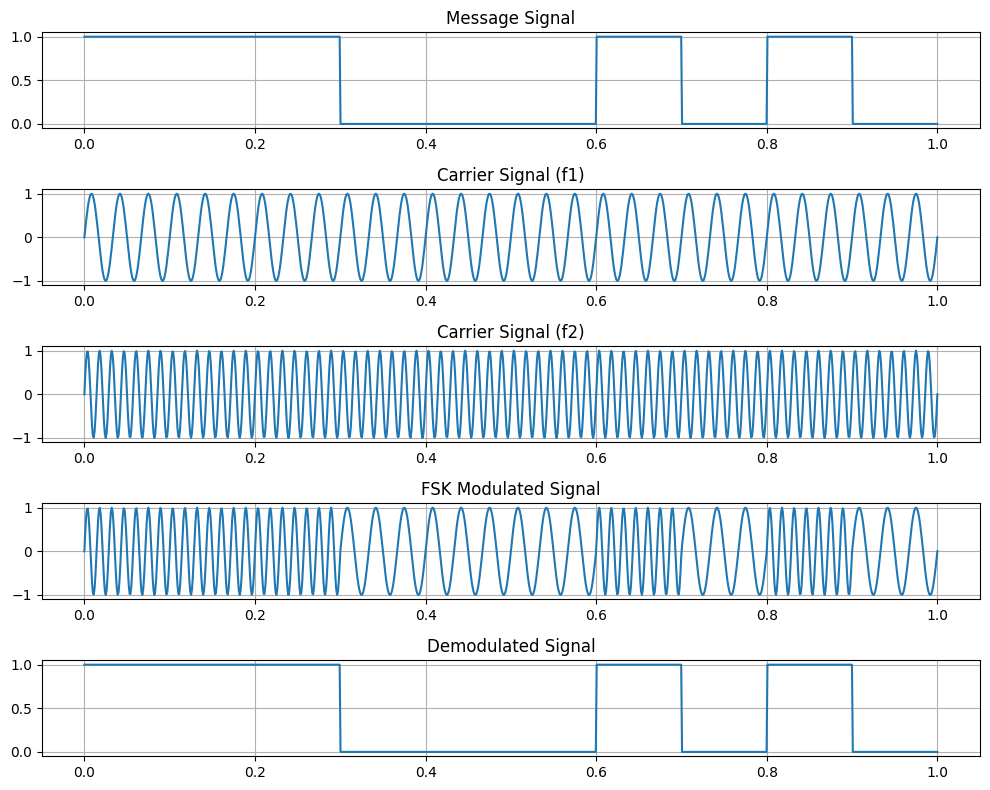

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

def lpf(x, fc, fs):
    b, a = butter(4, fc/(0.5*fs))
    return lfilter(b, a, x)

fs = 1000
f1 = 30
f2 = 70
bit_rate = 10
T = 1

t = np.linspace(0, T, fs)

bits = np.random.randint(0, 2, bit_rate)
bit_duration = fs // bit_rate
msg = np.repeat(bits, bit_duration)

carrier_f1 = np.sin(2*np.pi*f1*t)
carrier_f2 = np.sin(2*np.pi*f2*t)

# BFSK Modulation
fsk_signal = np.zeros_like(t)
for i, bit in enumerate(bits):
    s, e = i*bit_duration, (i+1)*bit_duration
    fsk_signal[s:e] = np.sin(2*np.pi*(f2 if bit else f1)*t[s:e])

# Coherent Demodulation
corr_f1 = lpf(fsk_signal * carrier_f1, f2, fs)
corr_f2 = lpf(fsk_signal * carrier_f2, f2, fs)

decoded_bits = []
for i in range(bit_rate):
    s, e = i*bit_duration, (i+1)*bit_duration
    decoded_bits.append(
        1 if np.sum(corr_f2[s:e]**2) > np.sum(corr_f1[s:e]**2) else 0
    )

demodulated_signal = np.repeat(decoded_bits, bit_duration)

# Plots
plt.figure(figsize=(10,8))

plt.subplot(5,1,1)
plt.plot(t, msg); plt.title("Message Signal"); plt.grid()

plt.subplot(5,1,2)
plt.plot(t, carrier_f1); plt.title("Carrier Signal (f1)"); plt.grid()

plt.subplot(5,1,3)
plt.plot(t, carrier_f2); plt.title("Carrier Signal (f2)"); plt.grid()

plt.subplot(5,1,4)
plt.plot(t, fsk_signal); plt.title("FSK Modulated Signal"); plt.grid()

plt.subplot(5,1,5)
plt.plot(t, demodulated_signal); plt.title("Demodulated Signal"); plt.grid()

plt.tight_layout()
plt.show()
